In [1]:

import warnings
warnings.filterwarnings("ignore")

import gc
import joblib
from datetime import date, datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import optuna

# Sklearn — model selection
from sklearn.model_selection import train_test_split, StratifiedKFold

# Sklearn — pipeline e preprocessamento
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.feature_selection import VarianceThreshold

# Sklearn — métricas
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix
)

# Sklearn — modelos
from sklearn.linear_model  import LogisticRegression
from sklearn.ensemble      import RandomForestClassifier, GradientBoostingClassifier
from sklearn.inspection    import permutation_importance

# Modelos externos
import lightgbm as lgb
from lightgbm  import LGBMClassifier
from xgboost   import XGBClassifier
from catboost  import CatBoostClassifier

# Encoders
from category_encoders import TargetEncoder
import json

pd.set_option('display.float_format', '{:.4f}'.format)

hoje = date.today()

In [ ]:
RUNNING = True

In [34]:
#Base de treino:
#C:\Users\muril\Downloads\Home_Credit_Default_Risk\Outputs_Intermediarios\01train_bureau.parquet
#C:\Users\muril\Downloads\Home_Credit_Default_Risk\Outputs_Intermediarios\02train_installments.parquet
#C:\Users\muril\Downloads\Home_Credit_Default_Risk\Outputs_Intermediarios\03tain_creditcard.parquet
#C:\Users\muril\Downloads\Home_Credit_Default_Risk\Outputs_Intermediarios\04train_poscash.parquet
#C:\Users\muril\Downloads\Home_Credit_Default_Risk\Outputs_Intermediarios\05train_previous.parquet


#Base de teste:
#C:\Users\muril\Downloads\Home_Credit_Default_Risk\Outputs_Intermediarios\01test_bureau.parquet
#C:\Users\muril\Downloads\Home_Credit_Default_Risk\Outputs_Intermediarios\02test_installments.parquet
#C:\Users\muril\Downloads\Home_Credit_Default_Risk\Outputs_Intermediarios\03test_creditcard.parquet
#C:\Users\muril\Downloads\Home_Credit_Default_Risk\Outputs_Intermediarios\04test_poscash.parquet
#C:\Users\muril\Downloads\Home_Credit_Default_Risk\Outputs_Intermediarios\05test_previous.parquet

### Importando Book -> Tirando Mau na Origem e Target missing

In [2]:
df_treino = pd.read_parquet(r'C:\Users\muril\Downloads\Home_Credit_Default_Risk\Outputs_Intermediarios\02train_installments.parquet')
df_treino = df_treino[~df_treino['TARGET'].isna()]

df_teste = pd.read_parquet(r'C:\Users\muril\Downloads\Home_Credit_Default_Risk\Outputs_Intermediarios\02test_installments.parquet')

Importância de Variáveis

In [3]:
X = df_treino.drop(columns=['SK_ID_CURR','TARGET'])
y = df_treino['TARGET']

In [4]:
# 1- Remover variáveis com baixa variância

def remove_low_variance(X, threshold=0.01):
    X_num = X.select_dtypes(exclude='object')
    X_num_filled = X_num.fillna(X_num.median())  # VarianceThreshold não aceita NaN

    # Normaliza antes de checar variância, sem isso, o threshold absoluto
    # favorece colunas de escala grande (monetárias) e penaliza colunas de
    # escala pequena (razões, flags), independente do quanto elas variam de verdade
    scaler = StandardScaler()
    X_num_scaled = scaler.fit_transform(X_num_filled)

    selector = VarianceThreshold(threshold=threshold)
    selector.fit(X_num_scaled)  # descarta o output escalado — só queremos saber QUAIS colunas passam

    cols_selected = X_num.columns[selector.get_support()]
    return cols_selected


# 2- IV e KS univariados

def calcular_iv_ks(X, y, coluna, n_bins=10, min_amostra=500):
    '''Calcula IV (via WOE por bins) e KS univariado de uma variável numérica.
    Colunas com menos de min_amostra linhas não-nulas retornam NaN: com poucas
    amostras o qcut gera bins quase puros (só 0 ou só 1 de target) e o WOE
    explode pra valores absurdos de IV — é ruído de amostra pequena, não
    sinal real.'''
    dados = pd.DataFrame({'var': X[coluna], 'target': y}).dropna()
    pct_missing = round(X[coluna].isnull().mean() * 100, 2)

    if len(dados) < min_amostra or dados['target'].nunique() < 2:
        return {'variavel': coluna, 'iv': np.nan, 'ks': np.nan, 'pct_missing': pct_missing}

    try:
        dados['bin'] = pd.qcut(dados['var'], q=n_bins, duplicates='drop')
    except ValueError:
        return {'variavel': coluna, 'iv': np.nan, 'ks': np.nan, 'pct_missing': pct_missing}

    grp = dados.groupby('bin', observed=True)['target'].agg(['count', 'sum'])
    grp['bom'] = grp['count'] - grp['sum']
    grp['mau'] = grp['sum']
    total_bom = grp['bom'].sum()
    total_mau = grp['mau'].sum()

    grp['pct_bom'] = grp['bom'] / total_bom
    grp['pct_mau'] = grp['mau'] / total_mau
    grp['woe'] = np.log((grp['pct_bom'].replace(0, 1e-6)) / (grp['pct_mau'].replace(0, 1e-6)))
    grp['iv_bin'] = (grp['pct_bom'] - grp['pct_mau']) * grp['woe']
    iv = grp['iv_bin'].sum()

    grp_sorted = grp.sort_index()
    ks = (grp_sorted['pct_bom'].cumsum() - grp_sorted['pct_mau'].cumsum()).abs().max()

    return {
        'variavel': coluna,
        'iv': round(iv, 4),
        'ks': round(ks, 4),
        'pct_missing': pct_missing
    }


def iv_ks_filter(X, y, cols, iv_min=0.02, n_bins=10, min_amostra=500):
    '''Roda IV/KS para uma lista de colunas numéricas e filtra pelo IV mínimo.'''
    resultados = [calcular_iv_ks(X, y, c, n_bins=n_bins, min_amostra=min_amostra) for c in cols]
    df_iv = pd.DataFrame(resultados).sort_values('iv', ascending=False).reset_index(drop=True)
    cols_aprovadas = df_iv.loc[df_iv['iv'] >= iv_min, 'variavel'].tolist()
    return df_iv, cols_aprovadas


# 3- Correlação entre variáveis numéricas

def correlation_filter(X, threshold=0.90):

    X_num       = X.select_dtypes(include=np.number)
    corr_matrix = X_num.corr().abs()
    upper       = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    remove      = [column for column in upper.columns if any(upper[column] > threshold)]
    return remove


# 4- Feature importance LightGBM

def lgbm_feature_importance(X_train, y_train, cat_cols=None):
    X_fit = X_train.copy()
    if cat_cols:
        for c in cat_cols:
            X_fit[c] = X_fit[c].astype('category')

    model = LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42,
        verbose=-1
    )
    model.fit(X_fit, y_train, categorical_feature=cat_cols if cat_cols else 'auto')
    importance = pd.DataFrame({
        "variavel"  : X_fit.columns,
        "importance": model.feature_importances_
    }).sort_values("importance", ascending=False).reset_index(drop=True)
    return importance


# 5- Rodar seleção
#e o split é só um holdout estratificado simples

X_sel = X
y_sel = y

# Split ANTES da seleção — importância calculada só no treino
X_sel_train, X_sel_test, y_sel_train, _ = train_test_split(
    X_sel, y_sel, test_size=0.30, stratify=y_sel, random_state=42
)

print("Shape inicial:", X_sel_train.shape)

cat_cols_sel = X_sel_train.select_dtypes(include='object').columns.tolist()
print("Colunas categóricas identificadas:", len(cat_cols_sel))

# Baixa variância fit no treino
cols_lowvar = remove_low_variance(X_sel_train, threshold=0.01)
print("\nApós baixa variância:", len(cols_lowvar))

# IV/KS fit no treino
df_iv, cols_iv_aprovadas = iv_ks_filter(X_sel_train, y_sel_train, cols_lowvar, iv_min=0.02)
print("Após filtro de IV (>= 0.02):", len(cols_iv_aprovadas))
print(df_iv.head(15))

# Correlação fit no treino — só entre as já aprovadas por IV
cols_iv_ordenadas = df_iv[df_iv['variavel'].isin(cols_iv_aprovadas)].sort_values('iv', ascending=False)['variavel'].tolist()
corr_remove = correlation_filter(X_sel_train[cols_iv_ordenadas], threshold=0.90)
print("\nVariáveis removidas por correlação:", len(corr_remove))

cols_finais_num = [c for c in cols_iv_aprovadas if c not in corr_remove]
cols_finais = cols_finais_num + cat_cols_sel

X_final_train = X_sel_train[cols_finais]
print("Shape final após filtros:", X_final_train.shape)

# Importância LightGBM - (astype category + categorical_feature)
importance = lgbm_feature_importance(X_final_train, y_sel_train, cat_cols=cat_cols_sel)
importance

Shape inicial: (215257, 1529)
Colunas categóricas identificadas: 16

Após baixa variância: 1247
Após filtro de IV (>= 0.02): 390
                             variavel     iv     ks  pct_missing
0     BUR_MEAN_DAYS_CREDIT_ENDDATE_U9 0.4137 0.2116      99.7000
1        BUR_MEDIAN_AMT_CREDIT_SUM_U9 0.4017 0.2243      99.6300
2                        EXT_SOURCE_3 0.3995 0.2665      19.8600
3      BUR_MIN_DAYS_CREDIT_ENDDATE_U9 0.3990 0.2116      99.7000
4   BUR_MEDIAN_DAYS_CREDIT_ENDDATE_U9 0.3970 0.2116      99.7000
5           BUR_SUM_AMT_CREDIT_SUM_U9 0.3643 0.2183      99.6300
6           BUR_MAX_AMT_CREDIT_SUM_U9 0.3618 0.2306      99.6300
7                        EXT_SOURCE_1 0.3577 0.2421      56.3900
8          BUR_MEAN_AMT_CREDIT_SUM_U9 0.3534 0.2243      99.6300
9           BUR_MIN_AMT_CREDIT_SUM_U9 0.3410 0.2231      99.6300
10     BUR_MAX_DAYS_CREDIT_ENDDATE_U9 0.3105 0.2116      99.7000
11                       EXT_SOURCE_2 0.3067 0.2221       0.2100
12         BUR_MAX_AMT_CRE

,variavel,importance
0,ORGANIZATION_TYPE,238
1,EXT_SOURCE_1,141
2,EXT_SOURCE_2,121
3,EXT_SOURCE_3,117
4,BUR_MAX_RATIO_UTILIZACAO_CREDITO,93
...,...,...
147,ELEVATORS_AVG,0
148,NAME_TYPE_SUITE,0
149,FLAG_OWN_REALTY,0
150,FONDKAPREMONT_MODE,0


Salvando Lista das Top Variáveis

In [ ]:
if RUNNING:
    file_path_vars = r'C:\Users\muril\Downloads\Home_Credit_Default_Risk\Outputs_Modelo\Variaveis\vars_selecionadas-02-Installments.json'

    with open(file_path_vars, 'w', encoding='utf-8') as f:
        json.dump(vars, f, ensure_ascii=False, indent=2)

    print(f"{len(vars)} variáveis salvas em: {file_path_vars}")

else:
    file_path_vars = r'C:\Users\muril\Downloads\Home_Credit_Default_Risk\Outputs_Modelo\Variaveis\vars_selecionadas-02-Installments.json'

    with open(file_path_vars, 'r', encoding='utf-8') as f:
        vars = json.load(f)

    print(f"{len(vars)} variáveis carregadas.")
    print(vars[:5])

    importance = importance[importance['importance'] > 0]
    vars = importance['variavel'].to_list()
    vars = vars[:31]

## Parte 1 — Preparando os dados (sem treinar ainda)

In [6]:
# ATENÇÃO: aqui só preparamos os dados (split + imputação + encoding).

COLS_TIRAR_TREINO = ['SK_ID_CURR', 'TARGET']
cols_remover_treino = [c for c in COLS_TIRAR_TREINO if c in df_treino.columns]

X = df_treino.drop(columns=cols_remover_treino)
y = df_treino['TARGET']

X = X[vars]

# Base oficial de teste da Home Credit — guarda o SK_ID_CURR à parte,
# ele não entra no modelo mas é obrigatório na submissão final.
ids_teste = df_teste['SK_ID_CURR'].copy()
X_teste = df_teste[vars].copy()  # mesmas colunas selecionadas

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

# Guarda os SK_ID_CURR do holdout e do treino, alinhados por índice — vai
ids_train = df_treino.loc[X_train.index, 'SK_ID_CURR'].values
ids_test  = df_treino.loc[X_test.index,  'SK_ID_CURR'].values

# ======================================================
# Identificação das colunas
# ======================================================

cat_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = [c for c in X_train.columns if c not in cat_cols]

# ======================================================
# Missing numéricos (média calculada no treino)
# Aplicado nas 3 bases: X_train (fit), X_test (transform), X_teste (transform)
# ======================================================

medians = X_train[num_cols].median()

X_train[num_cols] = X_train[num_cols].fillna(medians)
X_test[num_cols]  = X_test[num_cols].fillna(medians)
X_teste[num_cols] = X_teste[num_cols].fillna(medians)

# ======================================================
# Missing categóricos
# ======================================================

mode = X_train[cat_cols].mode().iloc[0]

X_train[cat_cols] = X_train[cat_cols].fillna(mode)
X_test[cat_cols]  = X_test[cat_cols].fillna(mode)
X_teste[cat_cols] = X_teste[cat_cols].fillna(mode)

encoder = TargetEncoder(cols=cat_cols)

X_train = encoder.fit_transform(X_train, y_train)
X_test  = encoder.transform(X_test)
X_teste = encoder.transform(X_teste)

print("X_train:", X_train.shape, "| X_test:", X_test.shape, "| X_teste (Kaggle):", X_teste.shape)

# ======================================================
# Padronização — só usada pela LogisticRegression (sensível a escala).
# Modelos de árvore (RF/LightGBM/CatBoost/GradientBoosting) são invariantes
# a escala e continuam usando X_train/X_test/X_teste sem padronizar.
# ======================================================

scaler = StandardScaler()

X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test),  columns=X_test.columns,  index=X_test.index)
X_teste_scaled = pd.DataFrame(scaler.transform(X_teste), columns=X_teste.columns, index=X_teste.index)

X_train: (215257, 31) | X_test: (92254, 31) | X_teste (Kaggle): (48744, 31)


## Comparação de modelos

In [7]:
# ======================================================
# Função KS
# ======================================================

def ks_score(y_true, prob):
    fpr, tpr, _ = roc_curve(y_true, prob)
    return np.max(tpr - fpr)

# ======================================================
# Modelos
# (idêntico ao behavioral — a comparação de algoritmos não muda entre
# application e behavior, o que muda é a leitura das métricas)
# ======================================================

models = {

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=5,
        random_state=42,
        n_jobs=-1
    ),

    "LightGBM": LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        random_state=42,
        verbose=-1
    ),

    "CatBoost": CatBoostClassifier(
        iterations=300,
        learning_rate=0.05,
        depth=5,
        random_state=42,
        verbose=False
    ),

    "GradientBoosting": GradientBoostingClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        random_state=42
    ),

    "LogisticRegression": LogisticRegression(
        max_iter=2000,
        random_state=42,
        n_jobs=-1
    )
}

# ======================================================
# Avaliação
# NOTA: dataset desbalanceado (~8% TARGET=1). Accuracy/Precision/Recall
# usam threshold padrão de 0.5 do predict(), que nesse cenário tende a
# prever quase tudo como classe 0 (accuracy alta e enganosa, recall baixo).
# O critério de decisão real é ROC AUC / KS / Gini, como no behavioral.
#
# LogisticRegression usa X_train_scaled/X_test_scaled (padronizados) — é o
# único modelo sensível a escala; os demais usam os dados originais.
# ======================================================

resultados = []

for nome, modelo in models.items():

    X_tr = X_train_scaled if nome == "LogisticRegression" else X_train
    X_te = X_test_scaled if nome == "LogisticRegression" else X_test

    modelo.fit(X_tr, y_train)

    pred_train = modelo.predict(X_tr)
    prob_train = modelo.predict_proba(X_tr)[:, 1]

    auc_train  = roc_auc_score(y_train, prob_train)
    gini_train = 2 * auc_train - 1
    ks_train   = ks_score(y_train, prob_train)

    pred_test = modelo.predict(X_te)
    prob_test = modelo.predict_proba(X_te)[:, 1]

    auc_test  = roc_auc_score(y_test, prob_test)
    gini_test = 2 * auc_test - 1
    ks_test   = ks_score(y_test, prob_test)

    resultados.append({
        "Modelo": nome,
        "Accuracy Train": accuracy_score(y_train, pred_train),
        "Accuracy Test": accuracy_score(y_test, pred_test),
        "Precision Train": precision_score(y_train, pred_train, zero_division=0),
        "Precision Test": precision_score(y_test, pred_test, zero_division=0),
        "Recall Train": recall_score(y_train, pred_train, zero_division=0),
        "Recall Test": recall_score(y_test, pred_test, zero_division=0),
        "ROC AUC Train": auc_train,
        "ROC AUC Test": auc_test,
        "Gini Train": gini_train,
        "Gini Test": gini_test,
        "KS Train": ks_train,
        "KS Test": ks_test,
        "Gap AUC": auc_train - auc_test,
        "Gap KS": ks_train - ks_test,
        "Gap Accuracy": accuracy_score(y_train, pred_train) - accuracy_score(y_test, pred_test)
    })


resultado_modelos = (
    pd.DataFrame(resultados)
      .sort_values("ROC AUC Test", ascending=False)
      .round(4)
      .reset_index(drop=True)
)

resultado_modelos

,Modelo,Accuracy Train,Accuracy Test,Precision Train,Precision Test,Recall Train,Recall Test,ROC AUC Train,ROC AUC Test,Gini Train,Gini Test,KS Train,KS Test,Gap AUC,Gap KS,Gap Accuracy
0,LightGBM,0.9216,0.9195,0.7518,0.5272,0.0429,0.0299,0.8157,0.7702,0.6314,0.5403,0.4756,0.4053,0.0456,0.0703,0.0021
1,GradientBoosting,0.9230,0.9193,0.7855,0.5009,0.0643,0.0384,0.8080,0.7697,0.6160,0.5394,0.4628,0.4044,0.0383,0.0584,0.0038
2,CatBoost,0.9205,0.9198,0.6901,0.5822,0.0265,0.0238,0.7793,0.7689,0.5585,0.5378,0.4189,0.4037,0.0104,0.0152,0.0006
3,LogisticRegression,0.9191,0.9190,0.4620,0.4361,0.0129,0.0133,0.7491,0.7455,0.4983,0.4909,0.3724,0.3676,0.0037,0.0048,0.0001
4,Random Forest,0.9193,0.9193,0.0000,0.0000,0.0000,0.0000,0.7510,0.7416,0.5020,0.4831,0.3737,0.3586,0.0095,0.0151,0.0000


### Optuna - LGBM

In [ ]:
cv = StratifiedKFold(5, shuffle=True, random_state=42)

def obj(trial):

    model = lgb.LGBMClassifier(
        objective        = "binary",
        verbosity        = -1,
        random_state     = 42,
        n_estimators     = 3000,
        learning_rate    = trial.suggest_float("lr", 0.005, 0.03, log=True),
        num_leaves       = trial.suggest_int("nl", 6, 12),
        max_depth        = trial.suggest_int("md", 3, 3),
        min_child_samples= trial.suggest_int("mcs", 400, 1000),
        subsample        = trial.suggest_float("sub", 0.4, 0.7),
        subsample_freq   = 1,
        colsample_bytree = trial.suggest_float("col", 0.3, 0.6),
        reg_alpha        = trial.suggest_float("l1", 1.0, 50.0, log=True),
        reg_lambda       = trial.suggest_float("l2", 1.0, 50.0, log=True),
        max_bin          = trial.suggest_int("bin", 16, 64),
        min_split_gain   = trial.suggest_float("msg", 0.0, 2.0),
    )

    s_ks = []
    s_gap = []          # NOVO — monitora o gap treino-validação a cada fold
    iteracoes = []

    for tr, va in cv.split(X_train, y_train):
        model.fit(
            X_train.iloc[tr], y_train.iloc[tr],
            eval_set=[(X_train.iloc[va], y_train.iloc[va])],
            eval_metric='auc',
            callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
        )
        p_va = model.predict_proba(X_train.iloc[va])[:, 1]
        p_tr = model.predict_proba(X_train.iloc[tr])[:, 1]

        ks_va = ks_score(y_train.iloc[va].values, p_va)
        ks_tr = ks_score(y_train.iloc[tr].values, p_tr)

        s_ks.append(ks_va)
        s_gap.append(ks_tr - ks_va)   # NOVO — quanto maior, mais overfit nesse fold
        iteracoes.append(model.best_iteration_)

    trial.set_user_attr("mean_best_iteration", int(np.mean(iteracoes)))
    trial.set_user_attr("mean_ks", float(np.mean(s_ks)))
    trial.set_user_attr("mean_gap", float(np.mean(s_gap)))  # NOVO — só pra você acompanhar depois

    KS = np.mean(s_ks)
    print(f'ks = {KS:.4f} | gap = {np.mean(s_gap):.4f}')

    return KS


if RUNNING:
    study = optuna.create_study(direction="maximize")
    study.optimize(obj, n_trials=40)  # subi de 20 pra 40

    best_params = study.best_params
    melhor_ks = study.best_value
    n_estimators_final = study.best_trial.user_attrs["mean_best_iteration"]
    melhor_gap = study.best_trial.user_attrs["mean_gap"]

    print(f"\nMelhores parâmetros: {best_params}")
    print(f"Melhor KS (CV): {melhor_ks:.4f}")
    print(f"Gap (CV) do melhor trial: {melhor_gap:.4f}")
    print(f"Nº de árvores (média do CV): {n_estimators_final}")

else:
    best_params = {'lr': 0.0239082224179111, 'nl': 8, 'md': 3, 'mcs': 995, 'sub': 0.6261632892073064, 
                   'col': 0.5609321296321036, 'l1': 1.9934646768672932, 'l2': 1.742522926921282, 
                   'bin': 46, 'msg': 1.6727606449371468}
    
    n_estimators_final = 979

    print("Melhores parâmetros:", best_params)

In [ ]:
cv = StratifiedKFold(5, shuffle=True, random_state=42)


def obj(trial):

    model = lgb.LGBMClassifier(
        objective        = "binary",
        verbosity        = -1,
        random_state     = 42,
        n_estimators     = 3000,
        learning_rate    = trial.suggest_float("lr", 0.005, 0.03, log=True),
        num_leaves       = trial.suggest_int("nl", 6, 12),
        max_depth        = trial.suggest_int("md", 3, 3),
        min_child_samples= trial.suggest_int("mcs", 400, 1000),
        subsample        = trial.suggest_float("sub", 0.4, 0.7),
        subsample_freq   = 1,
        colsample_bytree = trial.suggest_float("col", 0.3, 0.6),
        reg_alpha        = trial.suggest_float("l1", 1.0, 50.0, log=True),
        reg_lambda       = trial.suggest_float("l2", 1.0, 50.0, log=True),
        max_bin          = trial.suggest_int("bin", 16, 64),
        min_split_gain   = trial.suggest_float("msg", 0.0, 2.0),
    )

    s_ks = []
    s_capture = []       # NOVO — concentração nos 2 primeiros decis, por fold
    iteracoes = []

    for tr, va in cv.split(X_train, y_train):
        model.fit(
            X_train.iloc[tr], y_train.iloc[tr],
            eval_set=[(X_train.iloc[va], y_train.iloc[va])],
            eval_metric='auc',
            callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
        )
        p = model.predict_proba(X_train.iloc[va])[:, 1]
        s_ks.append(ks_score(y_train.iloc[va].values, p))
        s_capture.append(capture_rate_top_decis(p, y_train.iloc[va].values, n_top_decis=2))  # NOVO
        iteracoes.append(model.best_iteration_)

    trial.set_user_attr("mean_best_iteration", int(np.mean(iteracoes)))
    trial.set_user_attr("mean_ks", float(np.mean(s_ks)))
    trial.set_user_attr("mean_capture", float(np.mean(s_capture))) 

    metrica_combinada = 0.4 * np.mean(s_ks) + 0.6 * np.mean(s_capture)
    print(f'ks = {0.4 * np.mean(s_ks)} | s_cpature = {0.6 * np.mean(s_capture)}')

    # Combina os dois objetivos — 40% KS geral + 60% concentração no topo
    return metrica_combinada


study = optuna.create_study(direction="maximize")
study.optimize(obj, n_trials=20)

print(study.best_value)
print(study.best_params)
print("KS médio do melhor trial:", study.best_trial.user_attrs["mean_ks"])
print("Capture rate médio do melhor trial:", study.best_trial.user_attrs["mean_capture"])

[I 2026-08-21 19:47:13,127] A new study created in memory with name: no-name-1e97bc44-0467-47a7-80c4-b4d96ee076f5
[I 2026-08-21 19:49:47,167] Trial 0 finished with value: 0.4900544744807665 and parameters: {'lr': 0.013298141376288044, 'nl': 12, 'md': 3, 'mcs': 677, 'sub': 0.47384962646348855, 'col': 0.30202536302329624, 'l1': 29.79022435198551, 'l2': 16.640768280643403, 'bin': 62, 'msg': 1.1325227828276647}. Best is trial 0 with value: 0.4900544744807665.
[I 2026-08-21 19:51:37,213] Trial 1 finished with value: 0.49547681133738014 and parameters: {'lr': 0.0218150276923142, 'nl': 8, 'md': 3, 'mcs': 533, 'sub': 0.4651473344744794, 'col': 0.5302635676071467, 'l1': 7.0637031359538245, 'l2': 3.8136913308729103, 'bin': 59, 'msg': 0.9560061734812029}. Best is trial 1 with value: 0.49547681133738014.
[I 2026-08-21 19:54:01,366] Trial 2 finished with value: 0.49515482576152814 and parameters: {'lr': 0.012271790733178642, 'nl': 11, 'md': 3, 'mcs': 623, 'sub': 0.5422578244621887, 'col': 0.4584199

0.497503544736328
{'lr': 0.0239082224179111, 'nl': 8, 'md': 3, 'mcs': 995, 'sub': 0.6261632892073064, 'col': 0.5609321296321036, 'l1': 1.9934646768672932, 'l2': 1.742522926921282, 'bin': 46, 'msg': 1.6727606449371468}
KS médio do melhor trial: 0.4175812244340598
Capture rate médio do melhor trial: 0.5507850916045068


Retreinando o modelo

In [17]:
# MELHOR CONFIGURAÇÃO OPTUNA — SALVAR E RETREINAR

best_params = study.best_params
best_trial = study.best_trial
n_estimators_final = best_trial.user_attrs["mean_best_iteration"]

print(f"Score combinado (CV): {study.best_value:.4f}")
print(f"KS +  (CV): {best_trial.user_attrs['mean_ks']:.4f}")               # NOVO — o KS de verdade
print(f"Capture Rate médio - top 2 decis (CV): {best_trial.user_attrs['mean_capture']:.4f}")  # NOVO
print(f"Melhores parâmetros: {best_params}")
print(f"Nº de árvores (média do CV): {n_estimators_final}")

# Retreina com os melhores parâmetros na base de treino completa,
# usando o número de árvores encontrado no CV (não mais 3000 fixo)
best_lgbm = lgb.LGBMClassifier(
    objective        = "binary",
    verbosity        = -1,
    random_state     = 42,
    n_estimators     = n_estimators_final,  # AJUSTADO
    learning_rate    = best_params["lr"],
    num_leaves       = best_params["nl"],
    max_depth        = best_params["md"],
    min_child_samples= best_params["mcs"],
    subsample        = best_params["sub"],
    subsample_freq   = 1,
    colsample_bytree = best_params["col"],
    reg_alpha        = best_params["l1"],
    reg_lambda       = best_params["l2"],
    max_bin          = best_params["bin"],
    min_split_gain   = best_params["msg"],
)

best_pipe_optuna = Pipeline([("model", best_lgbm)])
best_pipe_optuna.fit(X_train, y_train)

# KS Treino e Teste com o modelo optuna
y_prob_teste_optuna  = best_pipe_optuna.predict_proba(X_test)[:, 1]
y_prob_treino_optuna = best_pipe_optuna.predict_proba(X_train)[:, 1]

ks_teste_optuna  = ks_score(y_test.values,  y_prob_teste_optuna)
ks_treino_optuna = ks_score(y_train.values, y_prob_treino_optuna)

print(f"\nModelo Optuna — KS Treino : {ks_treino_optuna:.4f}")
print(f"Modelo Optuna — KS Teste  : {ks_teste_optuna:.4f}")
print(f"Gap                       : {(ks_treino_optuna - ks_teste_optuna):.4f}")

# Importância de variáveis
importance_optuna = pd.DataFrame({
    "feature"   : X_train.columns.tolist(),
    "importance": best_lgbm.feature_importances_
}).sort_values("importance", ascending=False)

# Métricas
y_pred_teste_optuna  = best_pipe_optuna.predict(X_test)
y_pred_treino_optuna = best_pipe_optuna.predict(X_train)

auc_treino = roc_auc_score(y_train, y_prob_treino_optuna)
auc_teste  = roc_auc_score(y_test, y_prob_teste_optuna)

# cocentração dos maus nos primeiros 2 decis:
capture_treino_optuna = capture_rate_top_decis(y_prob_treino_optuna, y_train, n_top_decis=2)
capture_teste_optuna  = capture_rate_top_decis(y_prob_teste_optuna, y_test, n_top_decis=2)

print(f"Capture Rate Treino (top 2 decis): {capture_treino_optuna:.4f}")
print(f"Capture Rate Teste  (top 2 decis): {capture_teste_optuna:.4f}")

df_resultado_optuna = pd.DataFrame([
    {
        "split"    : "Treino",
        "accuracy" : accuracy_score(y_train, y_pred_treino_optuna),
        "precision": precision_score(y_train, y_pred_treino_optuna),
        "recall"   : recall_score(y_train, y_pred_treino_optuna),
        "f1"       : f1_score(y_train, y_pred_treino_optuna),
        "auc"      : auc_treino,
        "gini"     : 2 * auc_treino - 1,
        "ks"       : ks_treino_optuna,
        "capture_top2": capture_treino_optuna   # NOVO
    },
    {
        "split"    : "Teste",
        "accuracy" : accuracy_score(y_test, y_pred_teste_optuna),
        "precision": precision_score(y_test, y_pred_teste_optuna),
        "recall"   : recall_score(y_test, y_pred_teste_optuna),
        "f1"       : f1_score(y_test, y_pred_teste_optuna),
        "auc"      : auc_teste,
        "gini"     : 2 * auc_teste - 1,
        "ks"       : ks_teste_optuna,
        "capture_top2": capture_teste_optuna    # NOVO
    }
])

display(df_resultado_optuna)

# Salva pipeline completo com todos os artefatos
joblib.dump({
    'model'  : best_pipe_optuna,
    'encoder': encoder,
    'vars'   : vars
}, r'C:\Users\muril\Downloads\Home_Credit_Default_Risk\Outputs_Modelo\Modelos\best_pipe_optuna_LightGBMV2.pkl')
print('Pipeline completo salvo.')

Score combinado (CV): 0.4975
KS +  (CV): 0.4176
Capture Rate médio - top 2 decis (CV): 0.5508
Melhores parâmetros: {'lr': 0.0239082224179111, 'nl': 8, 'md': 3, 'mcs': 995, 'sub': 0.6261632892073064, 'col': 0.5609321296321036, 'l1': 1.9934646768672932, 'l2': 1.742522926921282, 'bin': 46, 'msg': 1.6727606449371468}
Nº de árvores (média do CV): 1769

Modelo Optuna — KS Treino : 0.4389
Modelo Optuna — KS Teste  : 0.4121
Gap                       : 0.0268
Capture Rate Treino (top 2 decis): 0.5759
Capture Rate Teste  (top 2 decis): 0.5439


,split,accuracy,precision,recall,f1,auc,gini,ks,capture_top2
0,Treino,0.9202,0.6067,0.0336,0.0636,0.7910,0.5820,0.4389,0.5759
1,Teste,0.9196,0.5408,0.0311,0.0589,0.7724,0.5449,0.4121,0.5439


Pipeline completo salvo.


#### Construindo base de submissão (TARGET, SCORE)

In [12]:
# Probabilidades -> vão ser reaproveitadas na Parte 2 (faixas de risco)
y_prob_train = best_pipe_optuna.predict_proba(X_train_scaled)[:, 1]
y_prob_test  = best_pipe_optuna.predict_proba(X_test_scaled)[:, 1]
y_prob_kaggle = best_pipe_optuna.predict_proba(X_teste_scaled)[:, 1]

submissao = pd.DataFrame({
    'SK_ID_CURR': ids_teste,
    'SCORE': y_prob_kaggle
})

#submissao.to_csv('submissao_home_credit.csv', index=False)
submissao.head()

,SK_ID_CURR,SCORE
0,100001,0.0430
1,100005,0.4171
2,100042,0.1707
3,100065,0.1964
4,100066,0.0414


#### Visão de % da taxa de maus por ordenação do Decil (+ Taxa de maus nos primeirps Decis)

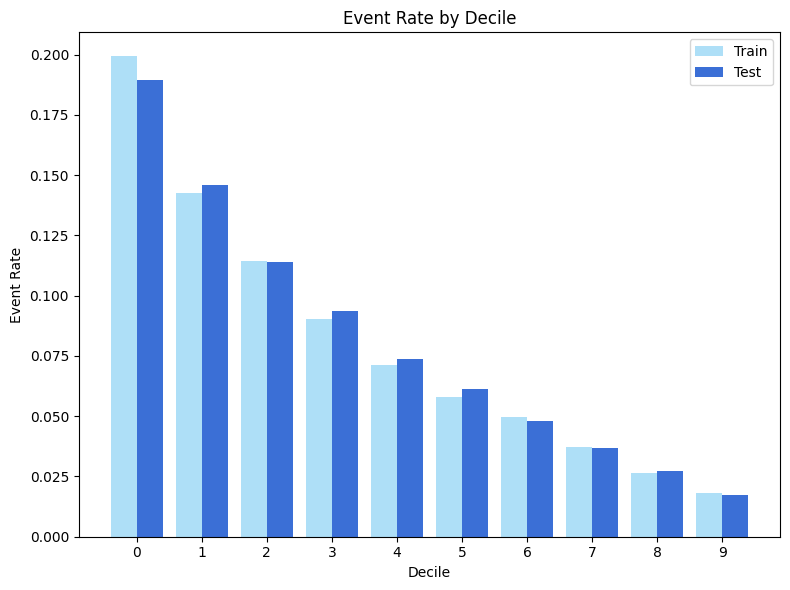

In [ ]:
N_DECIS = 10

def calcular_decis(score, y_true, n_decis=10):
    df = pd.DataFrame({
        'score': score,
        'target': np.asarray(y_true)
    })

    df['decil'] = pd.qcut(df['score'], q=n_decis, labels=False, duplicates='drop')

    return (
        df.groupby('decil')['target']
        .mean()
        .reindex(range(n_decis))
    )


score_train = (1 - y_prob_train) * 1000
score_test  = (1 - y_prob_test) * 1000

event_rate_train = calcular_decis(score_train, y_train, N_DECIS)
event_rate_test  = calcular_decis(score_test, y_test, N_DECIS)

# Gráfico de barras agrupadas

x = np.arange(N_DECIS)
largura = 0.4

plt.figure(figsize=(8, 6))
plt.bar(x - largura/2, event_rate_train.values, width=largura, label='Train', color='#AEDFF7')
plt.bar(x + largura/2, event_rate_test.values,  width=largura, label='Test',  color='#3B6FD6')

plt.xlabel('Decile')
plt.ylabel('Event Rate')
plt.title('Event Rate by Decile')
plt.xticks(x, [str(i) for i in range(N_DECIS)])
plt.legend()S
plt.tight_layout()
plt.show()

##### Visão de taxa de maus e taxa de maus acumulada por Decil

In [ ]:
def calcular_tabela_decis(y_prob, y_true, n_decis=10):
    """Gera tabela de decis com taxa de maus e taxa de maus acumulada.
    Decil 0 = maior risco (maior probabilidade prevista), Decil 9 = menor risco."""

    df = pd.DataFrame({
        'prob': y_prob,
        'target': np.asarray(y_true)
    })

    # qcut em -prob: decil 0 fica com as probabilidades mais altas (maior risco)
    df['decil'] = pd.qcut(-df['prob'], q=n_decis, labels=False, duplicates='drop')

    tabela = (
        df.groupby('decil')
        .agg(
            qtd_clientes = ('target', 'count'),
            qtd_maus     = ('target', 'sum')
        )
        .reindex(range(n_decis))  # garante que todos os decis 0-9 apareçam
        .reset_index()
    )

    tabela['taxa_maus'] = (tabela['qtd_maus'] / tabela['qtd_clientes'] * 100).round(2)
    tabela['taxa_maus_acumulada'] = (tabela['qtd_maus'].cumsum() / tabela['qtd_maus'].sum() * 100).round(2)

    return tabela


# Comparação do treino e  Teste

tabela_treino = calcular_tabela_decis(y_prob_treino_optuna, y_train, n_decis=10)
tabela_treino['split'] = 'Treino'

tabela_teste = calcular_tabela_decis(y_prob_teste_optuna, y_test, n_decis=10)
tabela_teste['split'] = 'Teste'

df_decis_completo = pd.concat([tabela_treino, tabela_teste], ignore_index=True)
df_decis_completo = df_decis_completo[['split', 'decil', 'qtd_clientes', 'qtd_maus', 'taxa_maus', 'taxa_maus_acumulada']]

display(df_decis_completo)